
# 🏷️ K Nearest Neighbors - MNIST dataset


![image](https://miro.medium.com/v2/resize:fit:640/format:webp/0*CCO8qrBn-J14H62o.png)

---

## 🎯 Objectius
- Aquest notebook pretén mostrar un exemple senzill d'ús d'un model KNN per classificar imatges que representent dígits escris a mà.
- Mirarem d'ajustar el model per tal de trobar els millors resultats.



## 📦 Dataset MNIST
En aquest notebook utlitzarem el conjunt de dades MNIST. Conjunt de 70.00 imatges petites de dígits escrits a mà.
Cada mostra està etiquetada amb el dígitt qur el representa (0-9).

Aquest cojunt de dades és un dels més utilitzats i se'l anomena el "Hola món!" dle la classificació d'imatges en Machine Lerning.
Cada vegada que algú troba un nou algorisme de classificació, sent curioristat com es comportarà amb el dataset MINST.

* Tenim 70.000 imatges
* Cada imatge té 784 caracrerístiques perquè són imatge de 28x28 pixels.
* Cada característica representa la intensitat d'un ixel, des de 0(blanc) a 255(negre)Al conjunt de dades MNIST, cada mostra és una imatge d’un dígit escrit a mà. Cada mostra inclou valors de píxels en escala de grisos de 28×28 com a característiques, i una etiqueta de classe categòrica entre 0 i 9. Per a més detalls, consulteu la pàgina del Dr. Yann LeCun (http://yann.lecun.com/exdb/mnist/
). El conjunt de dades s’ha importat utilitzant el paquet sklearn.dataset.


## 🟦 1. Import Classes

In [1]:
from collections import Counter
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import numpy as np
import ssl
ssl._create_default_https_context = ssl._create_unverified_context


# Definició d'una funció per mostrar un dígit mitjançant mmatplotlib.
def show_digit(x_vec, label, cmap="binary"):
    x_mat = x_vec.reshape(28, 28)
    plt.imshow(x_mat,cmap)
    plt.title('L\'etiqueta del dígit és: ' + label)
    plt.show()





## 🟦 1. Load Data

In [2]:

print("Carreguem el dataset mnist_784")
# Normalment el paquet de funcions sklearn.datasets retornen un objecte de tipus sklearn.utils.Bunch
# que són diccionaris amb les següent entrades: DESCR, data, target.
# També podríem haver utilitzar el paràmetre return_X_y=True per retornar directament X i y
df = fetch_openml('mnist_784', version=1, as_frame=False)
print(df.DESCR)

X, y = df.data, df.target
print(f'Tenim un total de {y.shape[0]} imatges')
print('Shape de les característiques:', X.shape)

Carreguem el dataset mnist_784
**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images w

In [3]:
y[0]

'5'

In [4]:
X[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

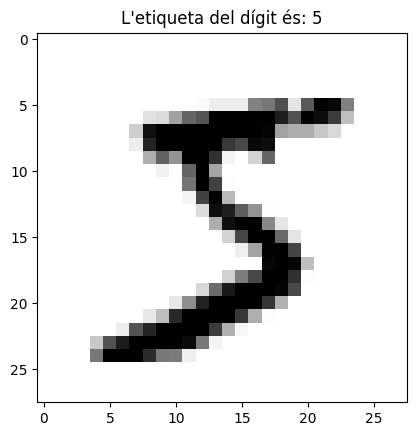

In [5]:
show_digit(X[0], y[0],"binary")

## 🟦 2. Preparació de les dades
En el cas del dataset MINST retorna un conjunt de dades d'entrenament i test encobert. Les **primeres 60.000 imatges** són de **Train** i les **10.000 següents** són de **Test**

Si fem un countplot veurem que els dos conjunts estan balancejats pel que fa a nivell de cada classe.

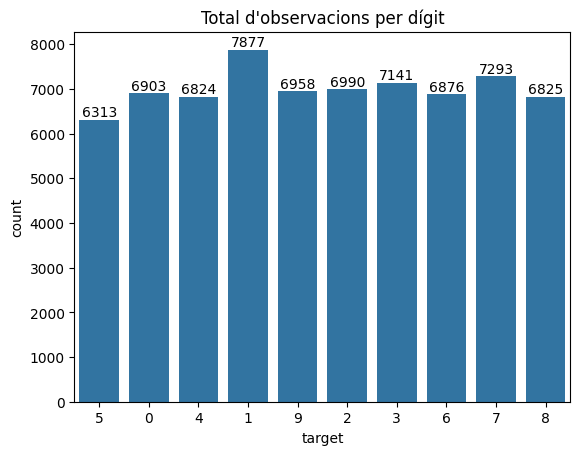

In [6]:
ax = sns.countplot(df, x="target")

# Añadir valores encima de cada barra
for container in ax.containers:
    ax.bar_label(container)
plt.title("Total d'observacions per dígit")
plt.show()

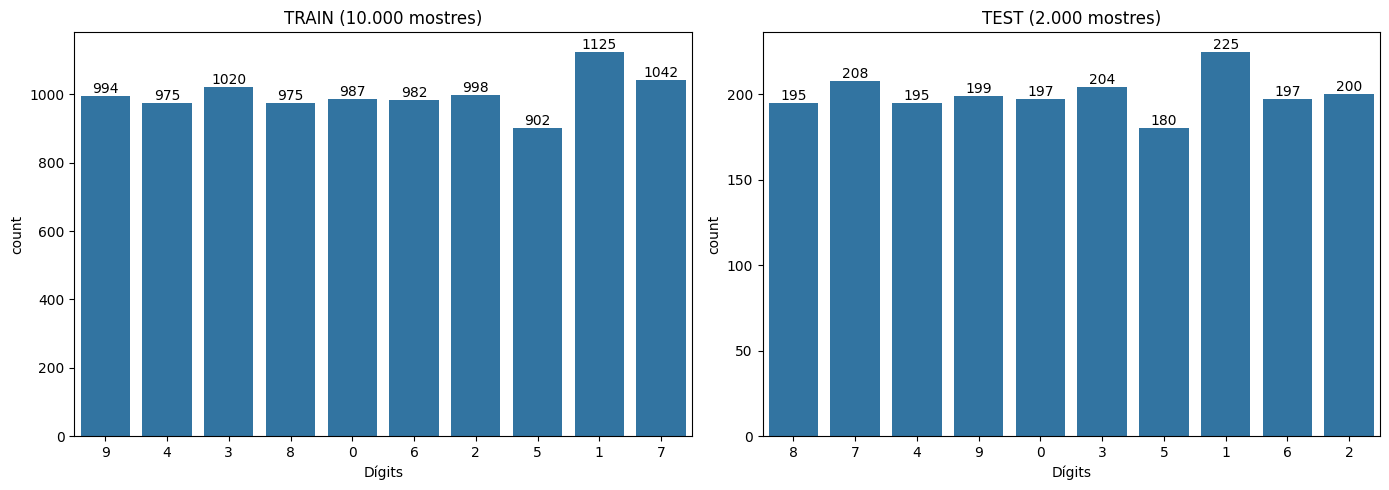

In [7]:
from sklearn.model_selection import train_test_split

# Agafarem un subconjunt de 12.000 observacions de les 70.000 que hi han.
X_small, _, y_small, _ = train_test_split(X, y, train_size=12000, random_state=42, stratify=y)

X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small, test_size=2000, random_state=42, stratify=y_small
)

# Utilitzarem menys dades. De
#X_train = X[:60000]
#X_test  = X[60000:]

#y_train = y[:60000].astype(int)
#y_test  = y[60000:].astype(int)




# Crear una figura amb dos subplots
plt.figure(figsize=(14, 5))

# --- TRAIN ---
plt.subplot(1, 2, 1)
ax1 = sns.countplot(x=y_train)
for container in ax1.containers:
    ax1.bar_label(container)
plt.title(f"TRAIN ({y_train.size:,} mostres)".replace(',','.'))
plt.xlabel("Dígits")

# --- TEST ---
plt.subplot(1, 2, 2)
ax2 = sns.countplot(x=y_test)
for container in ax2.containers:
    ax2.bar_label(container)
plt.title(f"TEST ({y_test.size:,} mostres)".replace(',','.'))
plt.xlabel("Dígits")

plt.tight_layout()
plt.show()


## 🟦 3. Entrenament

In [8]:
from sklearn.neighbors import KNeighborsClassifier

k = 3
model = KNeighborsClassifier(n_neighbors = k)
print("\nEntrenant KNN...")
t0 = time.time()
model.fit(X_train,y_train)
t1 = time.time()
print(f"Temps d'entrenament: {t1 - t0:.3f} segons")


Entrenant KNN...
Temps d'entrenament: 0.010 segons


## 🟦 4. Avaluació


Predint...
Temps de predicció: 1.163 segons
Accuracy global per K=3  0.9455
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       197
           1       0.91      1.00      0.95       225
           2       0.98      0.90      0.93       200
           3       0.96      0.95      0.95       204
           4       0.95      0.95      0.95       195
           5       0.94      0.93      0.94       180
           6       0.96      0.98      0.97       197
           7       0.94      0.96      0.95       208
           8       0.96      0.89      0.92       195
           9       0.93      0.91      0.92       199

    accuracy                           0.95      2000
   macro avg       0.95      0.94      0.95      2000
weighted avg       0.95      0.95      0.95      2000



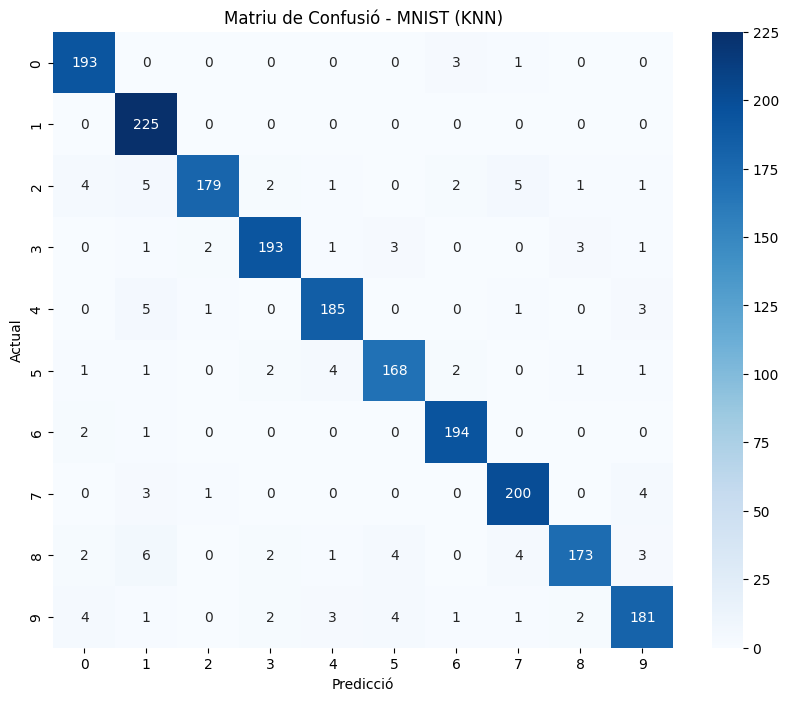

In [9]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

print("\nPredint...")
t0 = time.time()
y_pred = model.predict(X_test)
t1 = time.time()
print(f"Temps de predicció: {t1 - t0:.3f} segons")

print(f"Accuracy global per K={k} ",accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriu de Confusió - MNIST (KNN)")
plt.xlabel("Predicció")
plt.ylabel("Actual")
plt.show()

Si intentem de predir les **70.000** imatge veurem que els temps de predicció se'ns multiplica moltíssim ja que KNN és un model que escala molt malament per fet de cada punt l'ha de comparar amb els altres punts del dataset.


Predint...
Temps de predicció: 43.503 segons
Accuracy global per K=3  0.9528142857142857
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      6903
           1       0.93      0.99      0.96      7877
           2       0.97      0.94      0.95      6990
           3       0.94      0.95      0.94      7141
           4       0.96      0.94      0.95      6824
           5       0.94      0.94      0.94      6313
           6       0.97      0.98      0.98      6876
           7       0.95      0.96      0.95      7293
           8       0.98      0.89      0.93      6825
           9       0.93      0.94      0.93      6958

    accuracy                           0.95     70000
   macro avg       0.95      0.95      0.95     70000
weighted avg       0.95      0.95      0.95     70000



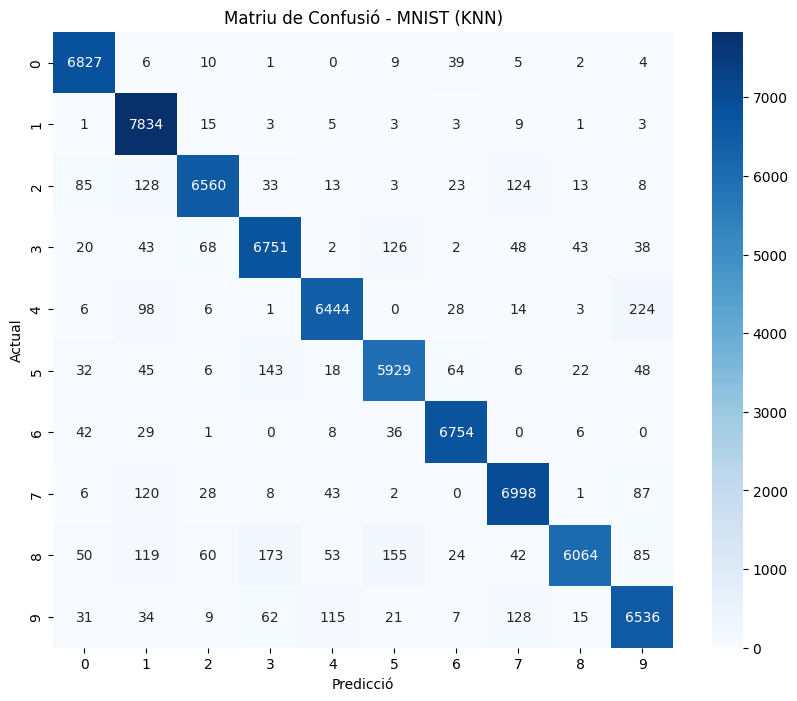

In [10]:
print("\nPredint...")
t0 = time.time()
y_pred = model.predict(X)
t1 = time.time()
print(f"Temps de predicció: {t1 - t0:.3f} segons")

print(f"Accuracy global per K={k} ",accuracy_score(y, y_pred))

print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriu de Confusió - MNIST (KNN)")
plt.xlabel("Predicció")
plt.ylabel("Actual")
plt.show()

## 🟦 4. Mirem a veure si podem trobar el millor valor de la K

In [51]:
error_rate = []
accuracy = []
train_pred_result = []
test_pred_result = []
imparells = lambda n: list(range(1, n + 1, 2))
k_values = imparells(40)

for i in k_values:
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train,y_train)
  y_pred = knn.predict(X_test)
  error_rate.append(np.mean(y_pred != y_test))
  accuracy.append(accuracy_score(y_test, y_pred))
  test_pred_result.append(y_pred)

df_result = pd.DataFrame()
df_result['K value'] = k_values
df_result['error_rate'] = error_rate
df_result['accuracy'] = accuracy
df_result


,K value,error_rate,accuracy
0,1,0.0560,0.9440
1,3,0.0545,0.9455
2,5,0.0555,0.9445
3,7,0.0545,0.9455
4,9,0.0550,0.9450
5,11,0.0595,0.9405
6,13,0.0650,0.9350
7,15,0.0685,0.9315
8,17,0.0720,0.9280
9,19,0.0730,0.9270


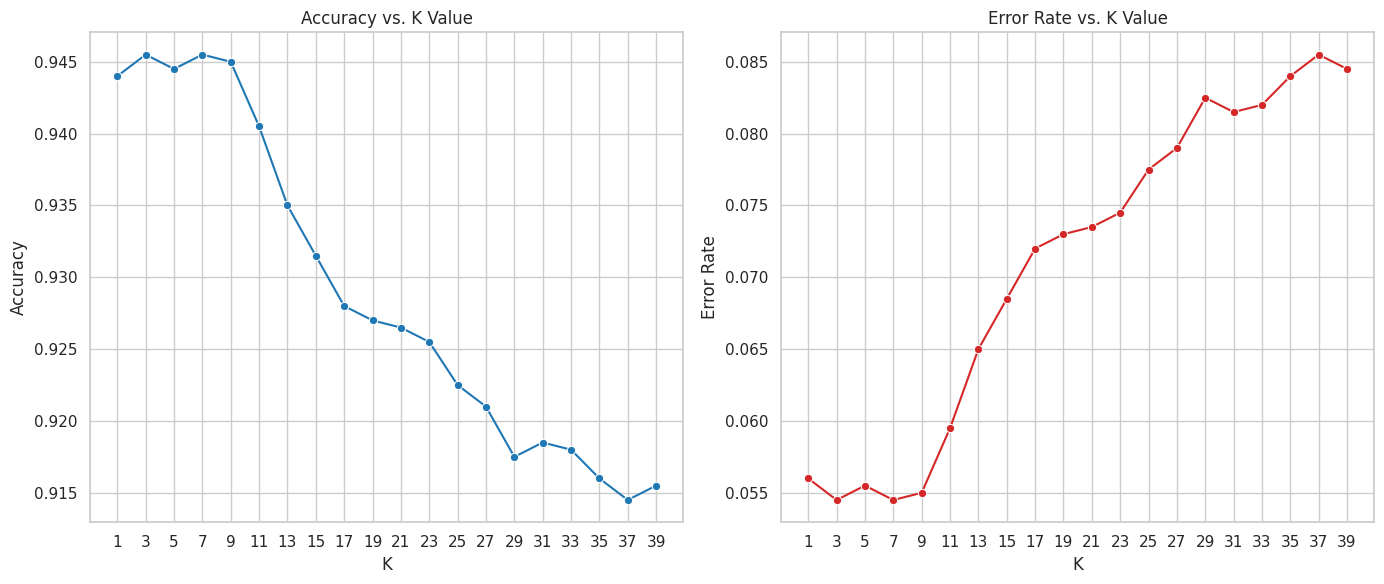

Accuracy màx: 0.9455 Error mínim: 0.0545 amb K = 3


In [50]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_palette('pastel')
#-- Primer plot: Accuracy
sns.lineplot(
    x=k_values,
    y=accuracy,
    marker='o',
    color='tab:blue',
    ax=axes[0]
)
axes[0].set_title('Accuracy vs. K Value')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(k_values)

# Mostrar valor sobre cada punt
#for x, y in zip(k_values, accuracy):
#    axes[0].text(x, y, f'{y:.2f}', ha='center', va='bottom', fontsize=8)

#-- Segon plot: Error Rate
sns.lineplot(
    x=k_values,
    y=error_rate,
    marker='o',
    color='tab:red',
    ax=axes[1]
)
axes[1].set_title('Error Rate vs. K Value')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Error Rate')
axes[1].set_xticks(k_values)

#for x, y in zip(k_values, error_rate):
#    axes[1].text(x, y, f'{y:.2f}', ha='center', va='bottom', fontsize=8)

#-- Plot sencer
plt.tight_layout()
plt.show()

print(
    "Accuracy màx:", max(accuracy),
    "Error mínim:", min(error_rate),
    "amb K =", k_values[error_rate.index(min(error_rate))]
)